In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## What will project cover?
1. Data Exploration
2. Data Preprocessing
3. Feature Encoding and Scaling
4. Classical ML Models:
       - Logistic Regression
       - K-Nearest Neighbors
       - Support Vector Machine
       - Decision Tree
       - Random Forest
       - XGBoost
 5. ANN
 6. Model Evaluation and Comparison
 7. Streamlit Inference
 8. Streamlit Deployment

In [2]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [3]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".csv"):
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
DATA_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

TARGET_COLUMN = "Churn"

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

RANDOM_STATE = 42
BATCH_SIZE = 32

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [7]:
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
def load_data(data_path: str) -> pd.DataFrame:
    """
    Load the tabular dataset from a CSV file.
    """
    
    data = pd.read_csv(data_path)

    print(f"Dataset loaded successfully.")
    print(f"Rows: {data.shape[0]}")
    print(f"Columns: {data.shape[1]}")

    return data

In [10]:
data = load_data(DATA_PATH)

Dataset loaded successfully.
Rows: 7043
Columns: 21


In [11]:
data.shape

(7043, 21)

In [12]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
data.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [14]:
# check missing values
def check_missing_values(
    data: pd.DataFrame
) -> pd.Series:
    """
    Return the number of missing values in every column.
    """

    missing_values = data.isnull().sum()

    return missing_values[missing_values > 0]

In [15]:
check_missing_values(data)

Series([], dtype: int64)

In [16]:
# target distribution
def visualize_target_distribution(
    data: pd.DataFrame,
    target_column: str
) -> None:
    """
    Visualize the target-class distribution.
    """

    target_counts = data[target_column].value_counts()

    plt.figure(figsize=(7, 5))

    plt.bar(
        target_counts.index,
        target_counts.values
    )

    plt.title("Target Distribution")
    plt.xlabel(target_column)
    plt.ylabel("Number of Customers")

    plt.show()

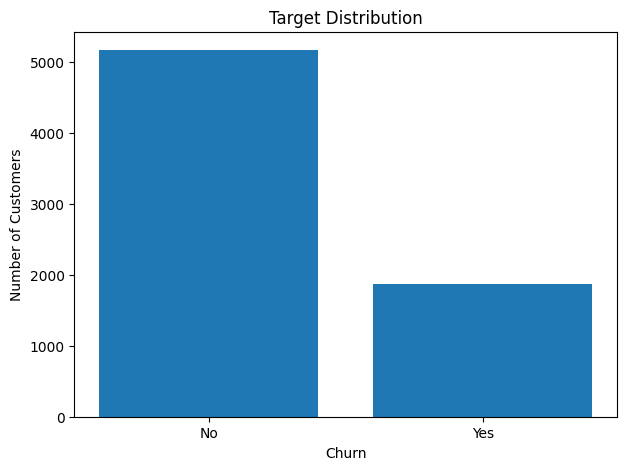

In [17]:
visualize_target_distribution(
    data,
    TARGET_COLUMN
)

In [18]:
# numerical features visualization
def visualize_numerical_features(
    data: pd.DataFrame,
    columns: list[str]
) -> None:
    """
    Visualize distributions of selected numerical features.
    """

    for column in columns:

        plt.figure(figsize=(7, 4))

        plt.hist(
            data[column].dropna(),
            bins=30
        )

        plt.title(f"{column} Distribution")
        plt.xlabel(column)
        plt.ylabel("Frequency")

        plt.show()

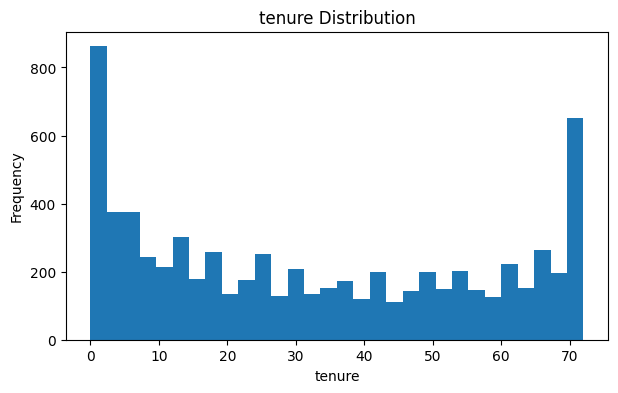

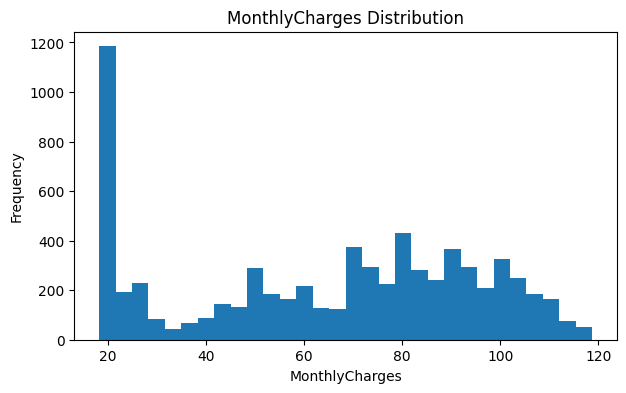

In [19]:
visualize_numerical_features(
    data,
    [
        "tenure",
        "MonthlyCharges"
    ]
)

In [20]:
# Categorical Features
def visualize_categorical_feature(
    data: pd.DataFrame,
    column: str
) -> None:
    """
    Visualize counts of a categorical feature.
    """

    counts = data[column].value_counts()

    plt.figure(figsize=(8, 5))

    plt.bar(
        counts.index,
        counts.values
    )

    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

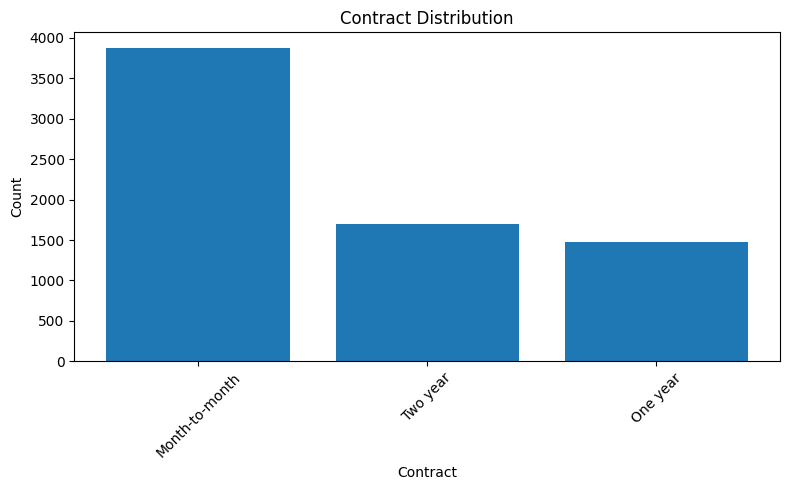

In [21]:
visualize_categorical_feature(
    data,
    "Contract"
)

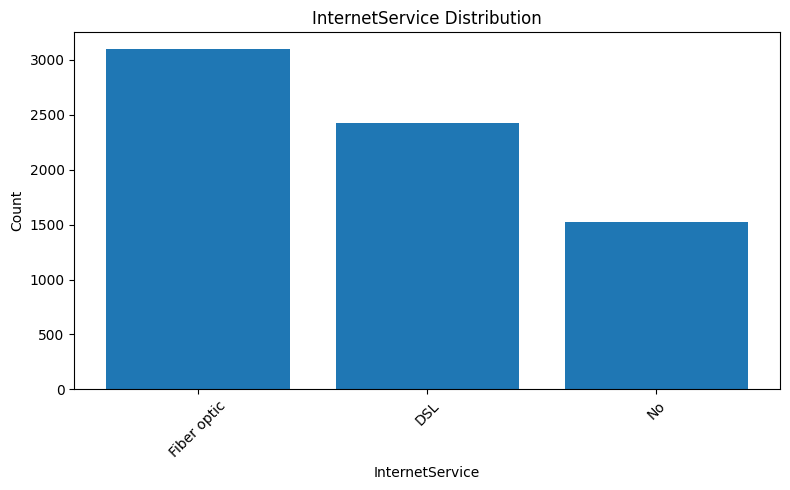

In [22]:
visualize_categorical_feature(
    data,
    "InternetService"
)

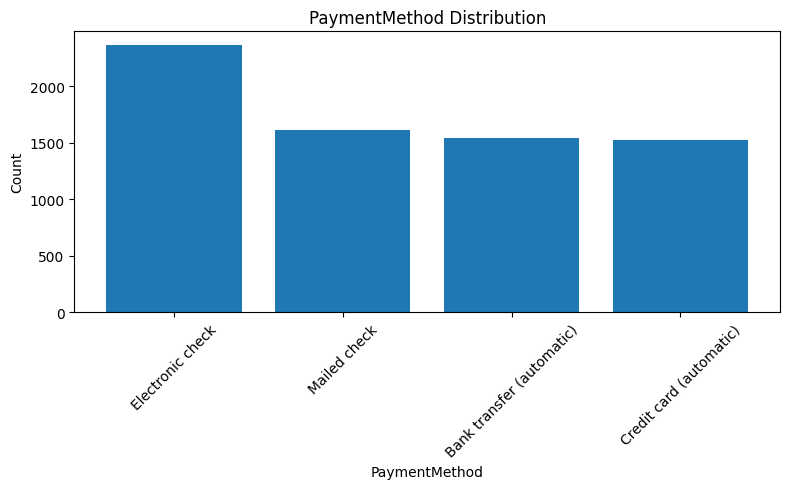

In [23]:
visualize_categorical_feature(
    data,
    "PaymentMethod"
)

In [24]:
# visualize feature vs target
def visualize_feature_vs_target(
    data: pd.DataFrame,
    feature: str,
    target: str
) -> None:
    """
    Visualize a categorical feature against the target.
    """

    comparison = pd.crosstab(
        data[feature],
        data[target],
        normalize="index"
    )

    comparison.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(f"{target} by {feature}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

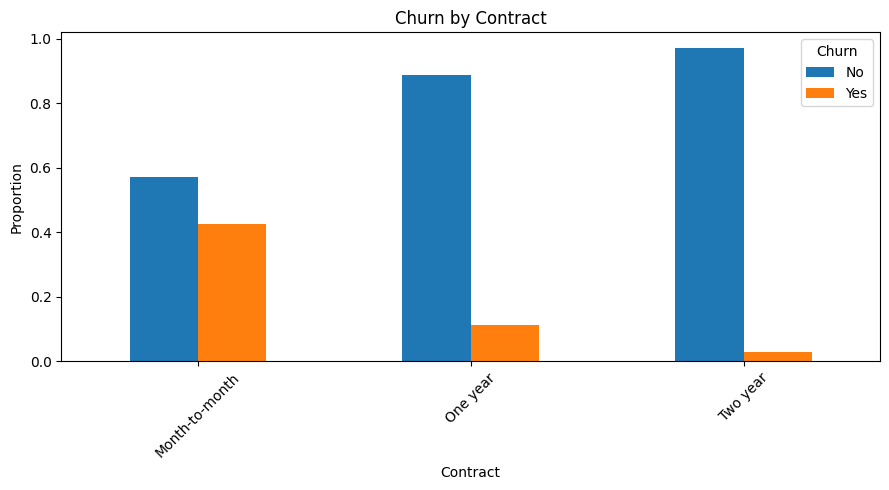

In [25]:
visualize_feature_vs_target(
    data,
    feature="Contract",
    target=TARGET_COLUMN
)

# Data cleaning

In [26]:
def clean_data(
    data: pd.DataFrame
) -> pd.DataFrame:
    """
    Clean the Telco Customer Churn dataset.
    """

    data = data.copy()

    # Customer ID is only an identifier
    if "customerID" in data.columns:
        data = data.drop(
            columns=["customerID"]
        )

    # Convert TotalCharges from object to numeric
    data["TotalCharges"] = pd.to_numeric(
        data["TotalCharges"],
        errors="coerce"
    )

    # Fill missing numerical values
    data["TotalCharges"] = data["TotalCharges"].fillna(
        data["TotalCharges"].median()
    )

    # Convert target into 0 and 1
    data["Churn"] = data["Churn"].map({
        "No": 0,
        "Yes": 1
    })

    return data

In [27]:
data = clean_data(data)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [30]:
data.isnull().sum().sum()

np.int64(0)

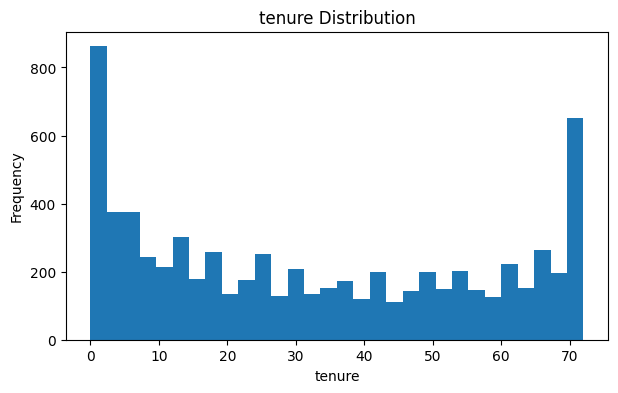

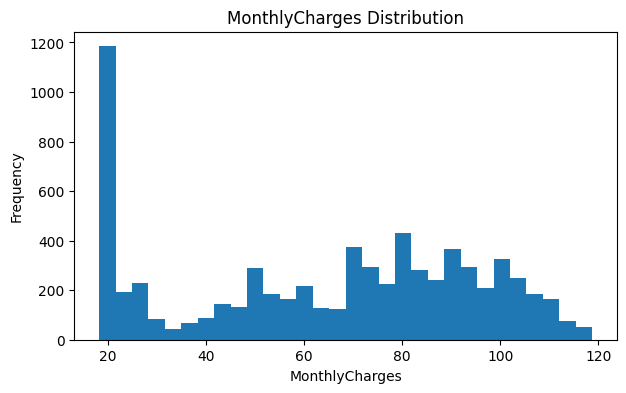

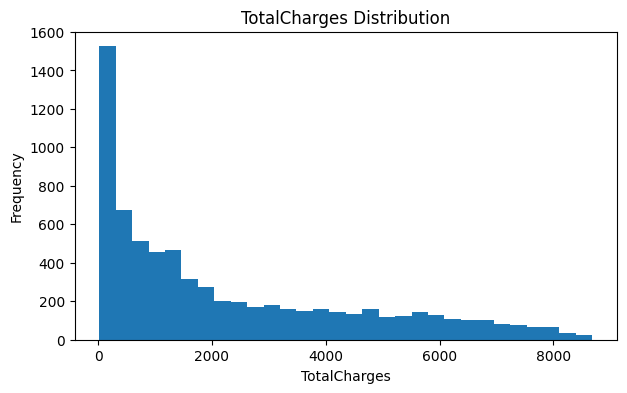

In [31]:
# Visualize TotalCharges
visualize_numerical_features(
    data,
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
)

In [32]:
# Separate Features and Target
def separate_features_target(
    data: pd.DataFrame,
    target_column: str
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Separate input features from the target.
    """

    x = data.drop(
        columns=[target_column]
    )

    y = data[target_column]

    return x, y

In [33]:
x, y = separate_features_target(
    data,
    TARGET_COLUMN
)

In [34]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [35]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [36]:
# data splitting
def split_data(
    x: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.20,
    validation_size: float = 0.20,
    random_state: int = 42
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
    pd.Series,
    pd.Series,
    pd.Series
]:
    """
    Split data into training, validation and testing sets.
    """

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    x_train, x_validation, y_train, y_validation = (
        train_test_split(
            x_train,
            y_train,
            test_size=validation_size,
            random_state=random_state,
            stratify=y_train
        )
    )

    return (
        x_train,
        x_validation,
        x_test,
        y_train,
        y_validation,
        y_test
    )

(
    x_train,
    x_validation,
    x_test,
    y_train,
    y_validation,
    y_test
) = split_data(
    x,
    y,
    test_size=TEST_SIZE,
    validation_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)

print("Training:", x_train.shape)
print("Validation:", x_validation.shape)
print("Testing:", x_test.shape)

Training: (4507, 19)
Validation: (1127, 19)
Testing: (1409, 19)


In [37]:
# Identify Numerical and Categorical Features
def get_feature_types(
    data: pd.DataFrame
) -> tuple[list[str], list[str]]:
    """
    Return numerical and categorical feature names.
    """

    numerical_columns = (
        data
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_columns = (
        data
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    return numerical_columns, categorical_columns

numerical_columns, categorical_columns = (
    get_feature_types(x_train)
)

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# Preprocessing
For tabular data:

Numerical
    ↓
StandardScaler


Categorical
    ↓
OneHotEncoder

In [38]:
def create_preprocessor(
    numerical_columns: list[str],
    categorical_columns: list[str]
) -> ColumnTransformer:
    """
    Create preprocessing pipeline for numerical
    and categorical features.
    """

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                StandardScaler(),
                numerical_columns
            ),

            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_columns
            )
        ]
    )

    return preprocessor

preprocessor = create_preprocessor(
    numerical_columns,
    categorical_columns
)

In [39]:
# Fit the Preprocessor
x_train_processed = preprocessor.fit_transform(
    x_train
)

x_validation_processed = preprocessor.transform(
    x_validation
)

x_test_processed = preprocessor.transform(
    x_test
)

In [40]:
print(
    "Training shape:",
    x_train_processed.shape
)

print(
    "Validation shape:",
    x_validation_processed.shape
)

print(
    "Testing shape:",
    x_test_processed.shape
)

Training shape: (4507, 45)
Validation shape: (1127, 45)
Testing shape: (1409, 45)


# Model results

In [41]:
model_results = []

In [42]:
def calculate_metrics(
    model_name: str,
    y_true,
    y_pred,
    training_time: float
) -> dict:
    """
    Calculate classification metrics.
    """

    results = {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "Training Time": training_time
    }

    model_results.append(results)

    return results

In [43]:
ml_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

In [44]:
def train_ml_model(
    model_name: str,
    model,
    x_train,
    y_train,
    x_test,
    y_test
):
    """
    Train and evaluate a classical ML model.
    """

    start_time = time.time()

    model.fit(
        x_train,
        y_train
    )

    training_time = (
        time.time() - start_time
    )

    predictions = model.predict(
        x_test
    )

    results = calculate_metrics(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions,
        training_time=training_time
    )

    print(f"\n{model_name}")
    print("-" * 50)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )

    return (
        model,
        predictions,
        results
    )

In [45]:
# Train All ML Models
trained_models = {}
ml_predictions = {}

for model_name, model in ml_models.items():

    (
        trained_model,
        predictions,
        results
    ) = train_ml_model(

        model_name=model_name,

        model=model,

        x_train=x_train_processed,
        y_train=y_train,

        x_test=x_test_processed,
        y_test=y_test
    )

    trained_models[model_name] = (
        trained_model
    )

    ml_predictions[model_name] = (
        predictions
    )


Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


K-Nearest Neighbors
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.83      0.83      1035
       Churn       0.54      0.55      0.54       374

    accuracy                           0.75      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.75      0.76      1409


Decision Tree
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.81      0.85      0.83      1035
       Churn       0.53    

# Deep Learning
```
Processed tabular features

         ↓
         
        ANN
        
         ↓
         
Binary churn prediction
```

In [46]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Create ANN Model
Output neurons = 1

Activation = sigmoid

Loss = binary_crossentropy

In [47]:
def create_ann_model(
    number_of_features: int
) -> tf.keras.Model:
    """
    Create an ANN model for binary tabular classification.
    """

    model = Sequential([

        Input(
            shape=(number_of_features,)
        ),

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            32,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

In [48]:
NUMBER_OF_FEATURES = (
    x_train_processed.shape[1]
)

In [49]:
NUMBER_OF_FEATURES

45

In [50]:
ann_model = create_ann_model(
    NUMBER_OF_FEATURES
)

ann_model.summary()

I0000 00:00:1786720182.359551      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786720182.365508      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

# Deep Learning Training Function

In [51]:
def train_deep_learning_model(
    model_name: str,
    model: tf.keras.Model,
    x_train,
    y_train,
    x_validation,
    y_validation,
    x_test,
    y_test,
    epochs: int = 15,
    batch_size: int = 32
):
    """
    Train and evaluate a binary deep-learning model.
    """

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,

        validation_data=(
            x_validation,
            y_validation
        ),

        epochs=epochs,
        batch_size=batch_size,

        callbacks=[
            early_stopping
        ]
    )

    training_time = (
        time.time() - start_time
    )

    probabilities = model.predict(
        x_test,
        verbose=0
    )

    predictions = (
        probabilities.flatten() >= 0.5
    ).astype(int)

    results = calculate_metrics(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions,
        training_time=training_time
    )

    print(f"\n{model_name}")
    print("-" * 50)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "No Churn",
                "Churn"
            ],
            zero_division=0
        )
    )

    return (
        model,
        history,
        predictions,
        results
    )

In [52]:
# train ann 
(
    ann_model,
    ann_history,
    ann_predictions,
    ann_results
) = train_deep_learning_model(

    model_name="ANN",

    model=ann_model,

    x_train=x_train_processed,
    y_train=y_train,

    x_validation=x_validation_processed,
    y_validation=y_validation,

    x_test=x_test_processed,
    y_test=y_test,

    epochs=20,
    batch_size=BATCH_SIZE
)

Epoch 1/20
 75/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6917 - loss: 0.5832

I0000 00:00:1786720230.025766     519 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7531 - loss: 0.4986 - val_accuracy: 0.8048 - val_loss: 0.4259
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7952 - loss: 0.4440 - val_accuracy: 0.8092 - val_loss: 0.4203
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4416 - val_accuracy: 0.8075 - val_loss: 0.4199
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.4368 - val_accuracy: 0.8057 - val_loss: 0.4198
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7921 - loss: 0.4318 - val_accuracy: 0.8083 - val_loss: 0.4170
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7994 - loss: 0.4249 - val_accuracy: 0.8119 - val_loss: 0.4157
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7974 - loss: 0.4202 - val_accuracy: 0.8128 - val_loss: 0.4161
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8079 - loss: 0.4215 - val_accuracy: 0.8146 - val

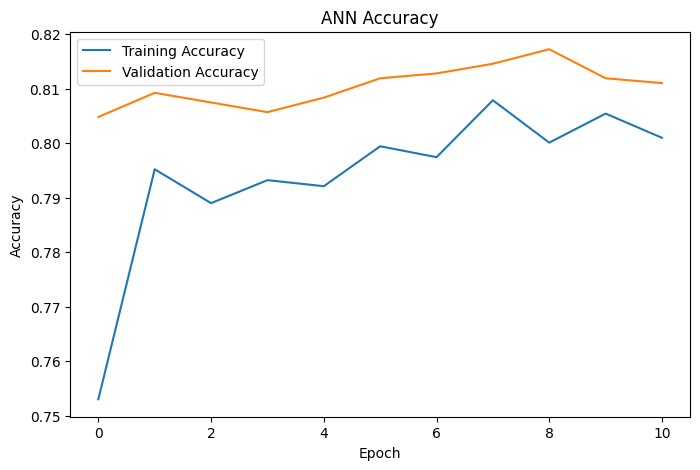

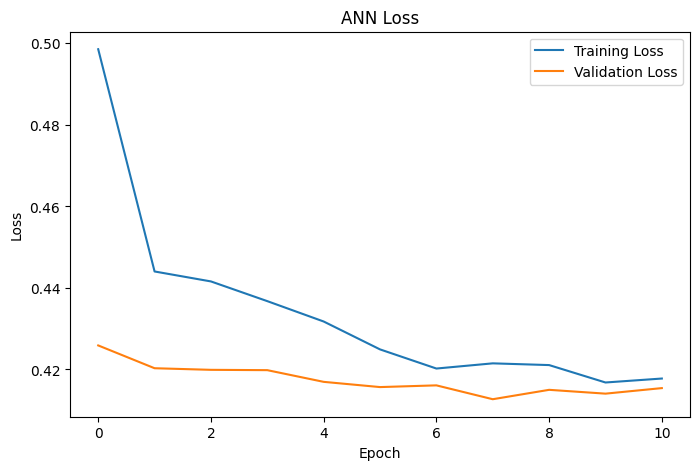

In [54]:
# training history
def plot_training_history(
    history: tf.keras.callbacks.History,
    model_name: str
) -> None:
    """
    Plot training and validation accuracy and loss.
    """

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        f"{model_name} Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()
    plt.show()


    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"{model_name} Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.show()

plot_training_history(
    ann_history,
    "ANN"
)

In [55]:
# Confusion Matrix Function
def plot_confusion_matrix(
    y_true,
    y_pred,
    class_names: list[str],
    model_name: str
) -> None:
    """
    Plot the confusion matrix.
    """

    matrix = confusion_matrix(
        y_true,
        y_pred
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names
    )

    display.plot(
        cmap="Blues"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.show()

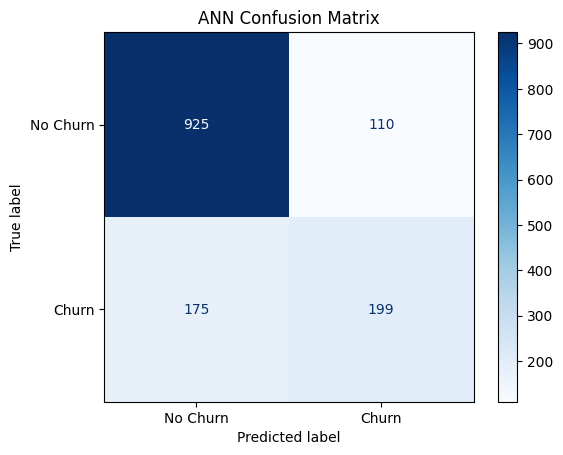

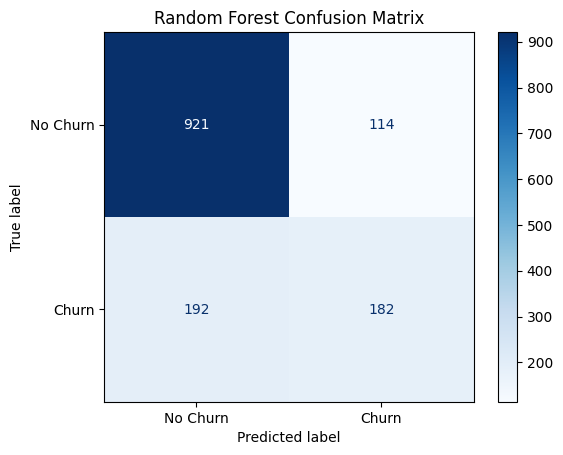

In [56]:
# ann
plot_confusion_matrix(
    y_true=y_test,
    y_pred=ann_predictions,
    class_names=[
        "No Churn",
        "Churn"
    ],
    model_name="ANN"
)

# random forest
plot_confusion_matrix(
    y_true=y_test,
    y_pred=ml_predictions[
        "Random Forest"
    ],
    class_names=[
        "No Churn",
        "Churn"
    ],
    model_name="Random Forest"
)

In [57]:
# Model Comparison Function
def compare_models(
    results: list[dict]
) -> pd.DataFrame:
    """
    Compare all trained models using their evaluation metrics.
    """

    results_df = pd.DataFrame(
        results
    )

    results_df = (
        results_df
        .sort_values(
            by="F1 Score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

    results_df[metric_columns] = (
        results_df[metric_columns]
        .round(4)
    )

    results_df["Training Time"] = (
        results_df["Training Time"]
        .round(2)
    )

    return results_df

comparison_df = compare_models(
    model_results
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Logistic Regression,0.7991,0.7908,0.7991,0.7933,0.07
1,ANN,0.7977,0.7886,0.7977,0.7912,10.38
2,XGBoost,0.7984,0.7872,0.7984,0.7889,0.65
3,Support Vector Machine,0.7906,0.7781,0.7906,0.7800,0.77
4,Random Forest,0.7828,0.7711,0.7828,0.7741,0.56
5,K-Nearest Neighbors,0.7544,0.7561,0.7544,0.7553,0.00
6,Decision Tree,0.7488,0.7395,0.7488,0.7433,0.03


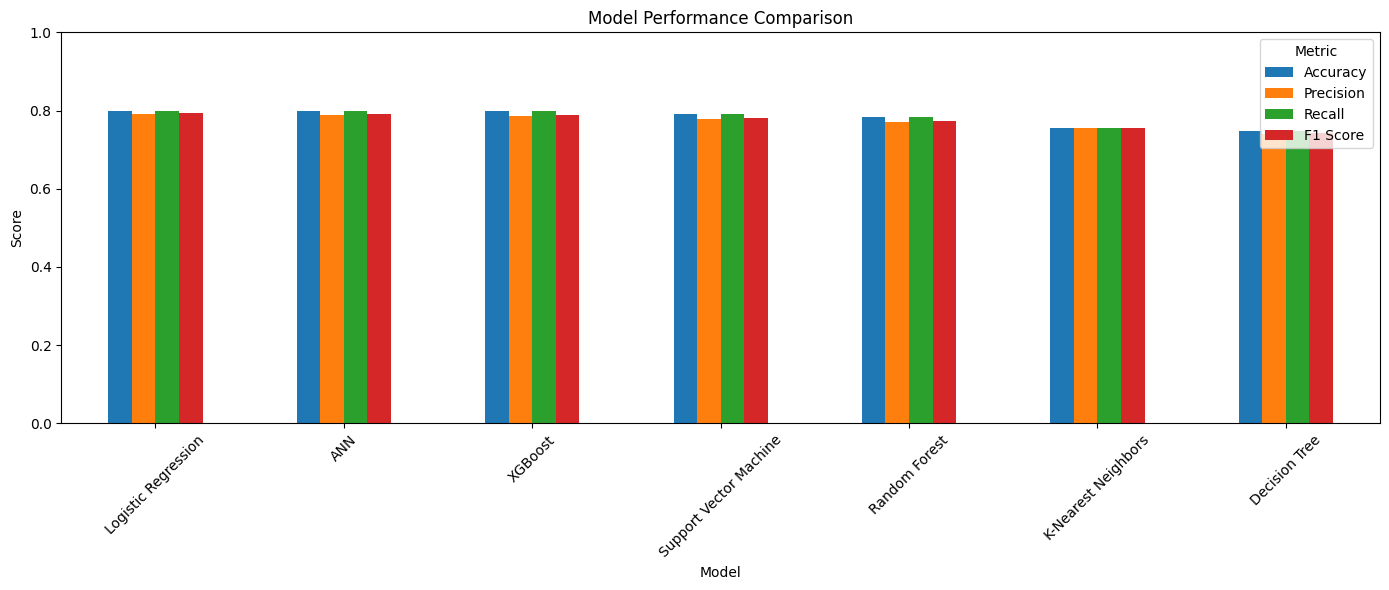

In [58]:
# Performance Visualization
def visualize_model_comparison(
    results_df: pd.DataFrame
) -> None:
    """
    Visualize model evaluation metrics.
    """

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

    comparison_plot = (
        results_df
        .set_index("Model")[metrics]
    )

    comparison_plot.plot(
        kind="bar",
        figsize=(14, 6)
    )

    plt.title(
        "Model Performance Comparison"
    )

    plt.xlabel("Model")
    plt.ylabel("Score")

    plt.ylim(0, 1)

    plt.xticks(
        rotation=45
    )

    plt.legend(
        title="Metric"
    )

    plt.tight_layout()
    plt.show()

visualize_model_comparison(
    comparison_df
)

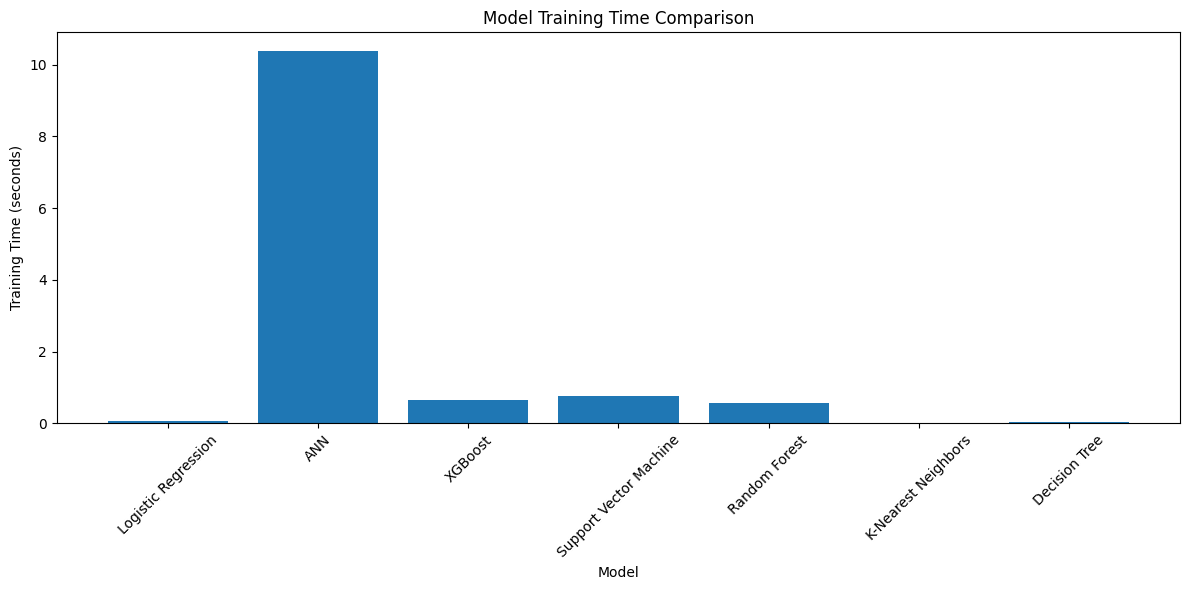

In [59]:
# Training-Time Visualization
def visualize_training_time(
    results_df: pd.DataFrame
) -> None:
    """
    Visualize training time for all models.
    """

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        results_df["Model"],
        results_df["Training Time"]
    )

    plt.title(
        "Model Training Time Comparison"
    )

    plt.xlabel("Model")
    plt.ylabel(
        "Training Time (seconds)"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()
    plt.show()

visualize_training_time(
    comparison_df
)

In [61]:
# Best-Model Function
def display_best_model(
    results_df: pd.DataFrame
) -> None:
    """
    Display the model with the highest F1 score.
    """

    if results_df.empty:
        print(
            "No model results found."
        )
        return

    best_model = (
        results_df.iloc[0]
    )

    print("Best Model")
    print("=" * 40)

    print(
        f"Model: {best_model['Model']}"
    )

    print(
        f"Accuracy: {best_model['Accuracy']}"
    )

    print(
        f"Precision: {best_model['Precision']}"
    )

    print(
        f"Recall: {best_model['Recall']}"
    )

    print(
        f"F1 Score: {best_model['F1 Score']}"
    )

    print(
        f"Training Time: "
        f"{best_model['Training Time']} seconds"
    )

display_best_model(
    comparison_df
)

Best Model
Model: Logistic Regression
Accuracy: 0.7991
Precision: 0.7908
Recall: 0.7991
F1 Score: 0.7933
Training Time: 0.07 seconds


In [62]:
# Save Results and Models
comparison_df.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

# Save the Preprocessor: OneHotEncoder + StandardScaler
import joblib
joblib.dump(
    preprocessor,
    "/kaggle/working/preprocessor.pkl"
)

['/kaggle/working/preprocessor.pkl']

# During Streamlit inference:
```
Customer data
     ↓
Saved preprocessor
     ↓
Encoded + scaled values
     ↓
Saved model
     ↓
Churn prediction
```
We never fit a new encoder or scaler on Streamlit inputs.

In [63]:
# Save ML Models
for model_name, model in trained_models.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    joblib.dump(
        model,
        f"/kaggle/working/{safe_name}.pkl"
    )

In [64]:
ann_model.save(
    "/kaggle/working/ann_model.keras"
)

# Final Structure

Now the two projects are deliberately very similar:

```
IMAGE PROJECT                       TABULAR PROJECT
────────────────────────────────────────────────────────

load_data()                         load_data()

visualize_images()                  visualize_target_distribution()
                                    visualize_numerical_features()
                                    visualize_categorical_feature()

HOG                                 OneHotEncoder
StandardScaler                      StandardScaler

train_ml_model()        ← SAME →    train_ml_model()

Logistic Regression                 Logistic Regression
KNN                                 KNN
Decision Tree                       Decision Tree
Random Forest                       Random Forest
SVM                                 SVM
XGBoost                             XGBoost

create_ann_model()                  create_ann_model()

train_deep_learning_model()         train_deep_learning_model()

CNN                                 —
VGG16                               —

calculate_metrics()     ← SAME →    calculate_metrics()

plot_training_history() ← SAME →    plot_training_history()

plot_confusion_matrix() ← SAME →    plot_confusion_matrix()

compare_models()        ← SAME →    compare_models()

visualize_model_comparison()        visualize_model_comparison()
                     ← SAME →

visualize_training_time()           visualize_training_time()
                     ← SAME →

display_best_model()    ← SAME →    display_best_model()

Streamlit                          Streamlit
```